# Quickstart: Synthetic Data with MANTRA

This tutorial introduces MANTRA's core workflow using synthetic data with a
known factor structure. You will learn how to:

1. Generate synthetic 3rd-order tensors
2. Fit a MANTRA model
3. Inspect training convergence
4. Extract and interpret embeddings (A1, A2, A3)
5. Compare recovered factors to the ground truth
6. Compute reconstruction error

## 1. Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch

import mantra
from mantra import MANTRA, DataGenerator

print(f"MANTRA imported successfully")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

MANTRA imported successfully
PyTorch version: 2.10.0
Device: cpu


/Users/Buettner/projects/MANTRA/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Generate Synthetic Data

`DataGenerator` creates a 3rd-order tensor $Y \in \mathbb{R}^{N \times J \times K}$
from known factor matrices:

$$Y_{ijk} = \sum_{r=1}^{R} A1_{ir} \cdot A2_{jr} \cdot A3_{kr} + \varepsilon_{ijk}$$

where $A1$ (samples), $A2$ (slices), and $A3$ (features) are the ground-truth
factor matrices.

In [2]:
N_SAMPLES = 50
N_SLICES = 8
N_FEATURES = 100
R = 5  # number of factors

gen = DataGenerator(n_samples=N_SAMPLES, n_drugs=N_SLICES, n_features=N_FEATURES, R=R)
gen.generate(seed=42)
data = gen.get_sim_data()

Y = data["Y_sim"]
print(f"Tensor shape: {Y.shape}  (samples x slices x features)")
print(f"Ground-truth factors: R = {R}")

Tensor shape: torch.Size([50, 8, 100])  (samples x slices x features)
Ground-truth factors: R = 5


## 3. Create and Fit the MANTRA Model

MANTRA uses variational inference (SVI) with Horseshoe priors for structured
sparsity. The `fit()` method returns the ELBO loss history and a flag
indicating whether early stopping was triggered.

In [3]:
model = MANTRA(
    observations=Y,
    R=R,
    use_gpu=False,
)
print(model)

MANTRA Model
  n_views:    1
  n_samples:  100
  n_factors:  5
  n_features: view_0: 100
  trained:    False
  device:     cpu


In [4]:
history, stopped_early = model.fit(
    n_epochs=1500,
    learning_rate=0.01,
    seed=42,
    verbose=True,
)
print(f"\nFinal ELBO: {history[-1]:.2f}")
print(f"Early stopped: {stopped_early}")

Training: 100%|███████████████████████████████████████████████████| 1500/1500 [00:10<00:00, 144.21it/s, ELBO=59985.27]


Final ELBO: 59985.27
Early stopped: False


## 4. Training Diagnostics

The ELBO (evidence lower bound) should decrease and stabilize during training.

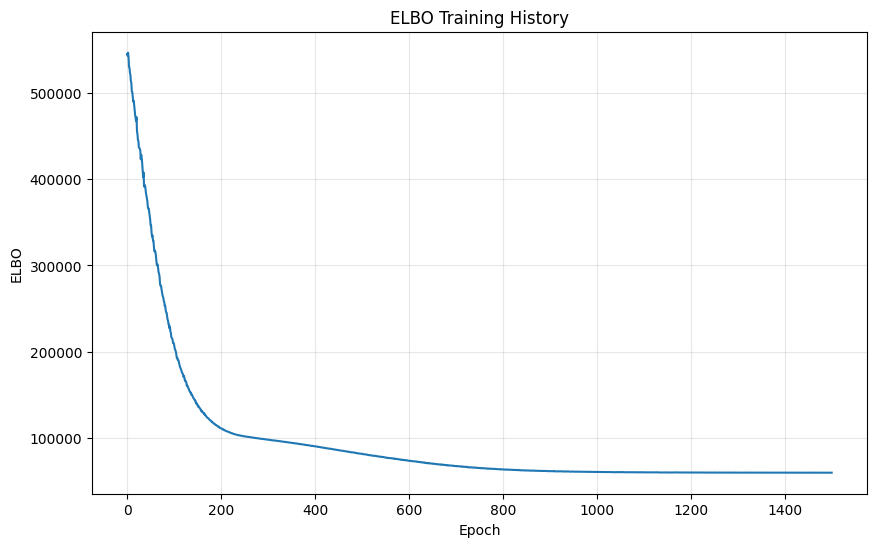

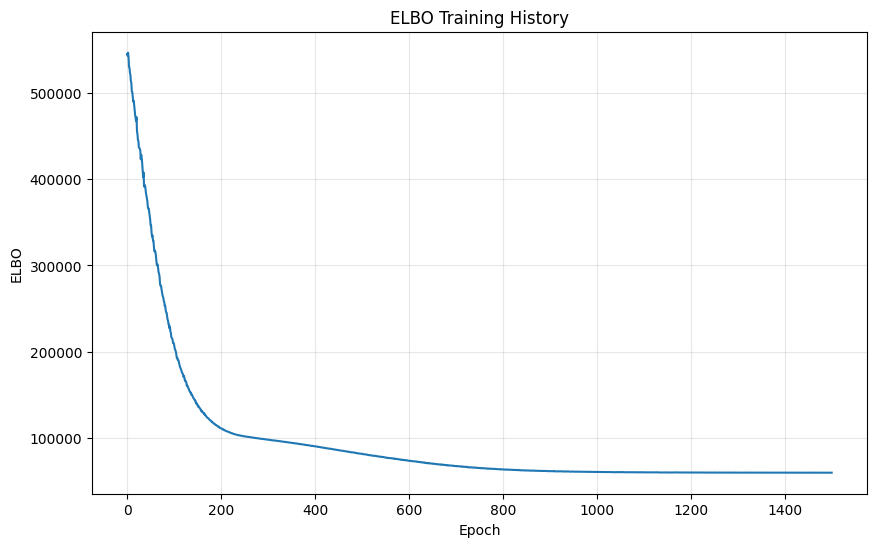

In [6]:
mantra.pl.plot_elbo(history)


## 5. Examine Posterior Distributions

After training, we can inspect the learned posterior distributions of the
factor matrices.

Posterior keys: ['tau', 'view_shrinkage', 'rank_scale', 'lmbda', 'A1', 'A2', 'local_scale', 'A3']


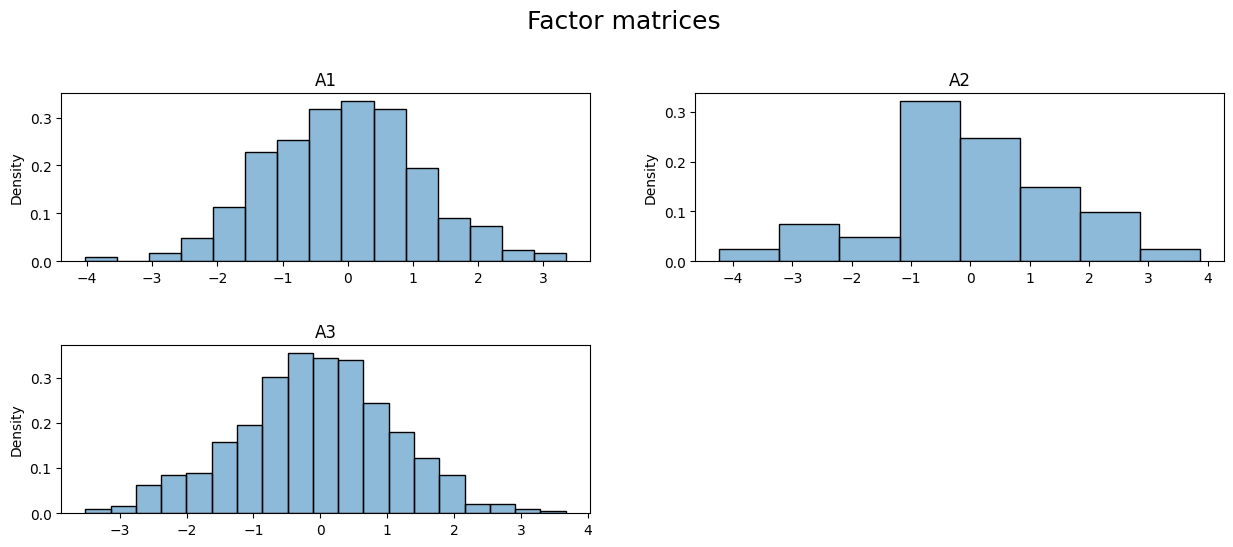

In [7]:
posterior = model.get_posterior()
print("Posterior keys:", list(posterior.keys()))

fig = mantra.pl.distplots(posterior, keyorder=["A1", "A2", "A3"])
plt.show()

## 6. Extract Embeddings

MANTRA decomposes the tensor into three factor matrices:

- **A1** (sample embeddings): how each sample scores on each factor
- **A2** (slice embeddings): how each slice scores on each factor
- **A3** (feature embeddings): how each feature scores on each factor

In [8]:
A1 = model.get_sample_embeddings(as_df=True)
A2 = model.get_slice_embeddings(as_df=True)
A3 = model.get_feature_embeddings(as_df=True)

print(f"A1 (samples):  {A1.shape}")
print(f"A2 (slices):   {A2.shape}")
print(f"A3 (features): {A3.shape}")

A1.head()

A1 (samples):  (50, 5)
A2 (slices):   (8, 5)
A3 (features): (100, 5)


,Factor_0,Factor_1,Factor_2,Factor_3,Factor_4
Sample_0,-2.268236,-1.284005,-1.328712,0.337892,-0.873131
Sample_1,-0.996834,0.010382,0.167821,-1.545759,0.380169
Sample_2,0.554961,-1.594559,0.975853,1.058257,-0.065471
Sample_3,-0.050394,-1.192034,0.435813,-1.006323,1.123936
Sample_4,-0.483047,0.200339,-0.846209,-0.197353,-1.432446


## 7. Compare Recovered Factors to Ground Truth

Factor models have inherent sign ambiguity: a factor in one run may appear with
the opposite sign in another. We therefore measure recovery quality via
**absolute correlation** between recovered and true factors.

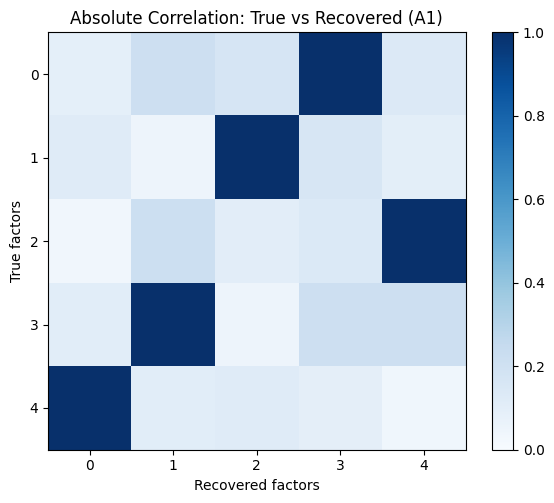

True factor 0 -> Recovered factor 3  (|r| = 1.000)
True factor 1 -> Recovered factor 2  (|r| = 1.000)
True factor 2 -> Recovered factor 4  (|r| = 1.000)
True factor 3 -> Recovered factor 1  (|r| = 1.000)
True factor 4 -> Recovered factor 0  (|r| = 1.000)


In [9]:
A1_true = data["A1_sim"].cpu().numpy()
A1_est = A1.values

# Compute absolute correlation matrix
corr_matrix = np.abs(np.corrcoef(A1_true.T, A1_est.T)[:R, R:])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix, vmin=0, vmax=1, cmap="Blues")
ax.set_xlabel("Recovered factors")
ax.set_ylabel("True factors")
ax.set_title("Absolute Correlation: True vs Recovered (A1)")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Best match per true factor
for r in range(R):
    best_match = np.argmax(corr_matrix[r])
    print(f"True factor {r} -> Recovered factor {best_match}  (|r| = {corr_matrix[r, best_match]:.3f})")

## 8. Variance Explained

`mantra.tl.variance_explained` computes the R-squared decomposition, showing
how much variance each factor captures.

In [10]:
r2 = mantra.tl.variance_explained(model)
print(f"Total R-squared: {r2['total']:.4f}")
print(f"\nPer-factor R-squared:")
print(r2["per_factor"])

Total R-squared: 0.9616

Per-factor R-squared:
                r2
Factor_1  0.352601
Factor_0  0.281566
Factor_4  0.221448
Factor_2  0.155941
Factor_3  0.141514


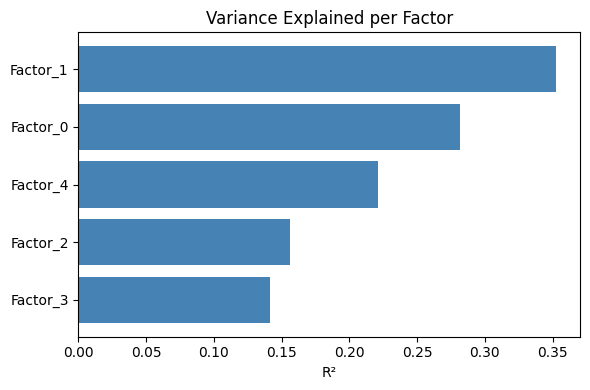

In [11]:
fig = mantra.pl.variance_explained(model)
plt.show()

## 9. Reconstruction Error

We can reconstruct the original tensor from the learned factors and measure
how close it is to the input.

In [13]:
Y_hat = model.get_reconstructed()
rmse = mantra.tl.rmse_loss(Y_hat, Y)
print(f"Reconstruction RMSE: {rmse:.4f}")


Reconstruction RMSE: 0.9864


## 10. Save and Load

MANTRA uses a pickle-free format (JSON + NPZ) for safe, portable model
persistence.

In [14]:
import tempfile
import os

with tempfile.TemporaryDirectory() as tmpdir:
    save_path = os.path.join(tmpdir, "quickstart_model")
    model.save(save_path)
    print(f"Saved to: {save_path}")
    print(f"Files: {os.listdir(save_path)}")

    # Load back
    model_loaded = MANTRA.load(save_path)
    print(f"\nLoaded model: trained={model_loaded._trained}")

    # Verify embeddings match
    A1_loaded = model_loaded.get_sample_embeddings()
    A1_orig = model.get_sample_embeddings()
    diff = torch.abs(A1_orig - A1_loaded).max().item()
    print(f"Max difference in A1 after load: {diff:.2e}")

Saved to: /var/folders/rr/63kswr8116v7hg6kbn11v8t40000gp/T/tmps9t_ul4m/quickstart_model
Files: ['params.npz', 'metadata.json', 'data.npz']

Loaded model: trained=True
Max difference in A1 after load: 0.00e+00


## Summary

In this tutorial you learned the core MANTRA workflow:

| Step | Function |
|------|----------|
| Generate data | `DataGenerator(...).generate()` |
| Create model | `MANTRA(observations, R=...)` |
| Train | `model.fit(n_epochs, learning_rate)` |
| Diagnostics | `mantra.pl.plot_elbo(history)` |
| Embeddings | `model.get_sample_embeddings()` etc. |
| Variance explained | `mantra.tl.variance_explained(model)` |
| Reconstruction | `model.get_reconstructed()` |
| Save/Load | `model.save(path)` / `MANTRA.load(path)` |

Next: [02_single_cell_rna.ipynb](02_single_cell_rna.ipynb) applies MANTRA to real
scRNA-seq data.